In [4]:
import pandas as pd
import numpy as np

from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import grangercausalitytests

import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv(r"D:\BE\BE\BE 8th Sem\Internship\Evostra Major Project\evoastra-capstone\evoastra-capstone\data\processed\DataCoSupplyChain_clean.csv")

print(df.shape)
df.head()

(124993, 57)


,type,days_for_shipping_real,days_for_shipment_scheduled,benefit_per_order,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_city,...,shipping_mode,order_year,order_month,order_day,order_weekday,is_weekend,shipping_delay,profit_margin,sales_per_item,order_size
0,1,3,4,91.250000,314.640015,0,0,73,36,66,...,3,2018,1,31,2,0,-1,0.278413,327.75,327.75
1,3,5,4,-249.089996,311.359985,1,1,73,36,66,...,3,2018,1,13,5,1,1,-0.760000,327.75,327.75
2,0,4,4,-247.779999,309.720001,3,0,73,36,452,...,3,2018,1,13,5,1,0,-0.756003,327.75,327.75
3,1,3,4,22.860001,304.809998,0,0,73,36,285,...,3,2018,1,13,5,1,-1,0.069748,327.75,327.75
4,2,2,4,134.210007,298.250000,0,0,73,36,66,...,3,2018,1,13,5,1,-2,0.409489,327.75,327.75


## Step 3 — Hypothesis Definition

To statistically validate supply chain patterns, the following hypotheses are tested.

### Hypothesis 1: Shipping Mode vs Delivery Delay
H0: Shipping mode does NOT affect delivery delay  
H1: Shipping mode affects delivery delay  

Test Used: **ANOVA**

---

### Hypothesis 2: Customer Segment vs Sales
H0: Customer segments have the same average sales  
H1: Customer segments have different average sales  

Test Used: **ANOVA**

---

### Hypothesis 3: Product Category vs Late Delivery Risk
H0: Product category and late delivery risk are independent  
H1: Product category and late delivery risk are dependent  

Test Used: **Chi-Square Test**

---

### Hypothesis 4: Seasonal Demand
H0: Demand does NOT vary by month  
H1: Demand varies seasonally  

Test Used: **ANOVA**

---

### Hypothesis 5: Shipping Delay vs Sales Trend
H0: Shipping delay does NOT influence sales over time  
H1: Shipping delay influences sales over time  

Test Used: **Granger Causality Test**

In [6]:
df.columns

Index(['type', 'days_for_shipping_real', 'days_for_shipment_scheduled',
       'benefit_per_order', 'sales_per_customer', 'delivery_status',
       'late_delivery_risk', 'category_id', 'category_name', 'customer_city',
       'customer_country', 'customer_id', 'customer_segment', 'customer_state',
       'customer_street', 'customer_zipcode', 'department_id',
       'department_name', 'latitude', 'longitude', 'market', 'order_city',
       'order_country', 'order_customer_id', 'order_date_dateorders',
       'order_id', 'order_item_cardprod_id', 'order_item_discount',
       'order_item_discount_rate', 'order_item_id', 'order_item_product_price',
       'order_item_profit_ratio', 'order_item_quantity', 'sales',
       'order_item_total', 'order_profit_per_order', 'order_region',
       'order_state', 'order_status', 'order_zipcode', 'product_card_id',
       'product_category_id', 'product_description', 'product_name',
       'product_price', 'product_status', 'shipping_date_dateorders

Step 4: t-Test (Weekend vs Weekday Sales)

Explanation :
If p < 0.05, we write:

The independent t-test indicates that weekend and weekday sales differ significantly, suggesting customer purchasing behavior varies across the week.

If p > 0.05, we write:

The t-test shows no statistically significant difference between weekend and weekday sales.

In [7]:
from scipy import stats

# Separate weekend and weekday sales
weekend = df[df['is_weekend'] == 1]['sales']
weekday = df[df['is_weekend'] == 0]['sales']

# Perform t-test
t_stat, p_value = stats.ttest_ind(weekend, weekday)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -0.9751690734630877
P-value: 0.3294782873580083


In [8]:
if p_value < 0.05:
    print("Reject H0 → Sales differ between weekend and weekday")
else:
    print("Fail to reject H0 → No significant difference")

Fail to reject H0 → No significant difference


### T-Test Result: Weekend vs Weekday Sales

An independent t-test was conducted to determine whether sales differ between weekends and weekdays.

H0: Sales are the same for weekend and weekday  
H1: Sales differ between weekend and weekday

Results:
T-statistic = -0.975  
P-value = 0.329

Since the p-value is greater than 0.05, we fail to reject the null hypothesis.

Conclusion:
There is no statistically significant difference in sales between weekends and weekdays.

ANOVA TEST :

H0: Shipping mode does NOT affect delivery delay
H1: Shipping mode affects delivery delay

In [9]:
groups = [group["shipping_delay"].values 
          for name, group in df.groupby("shipping_mode")]

from scipy import stats

f_stat, p_value = stats.f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 17010.951156702948
P-value: 0.0


In [10]:
if p_value < 0.05:
    print("Reject H0 → Shipping mode significantly affects delivery delay")
else:
    print("Fail to reject H0 → Shipping mode does not significantly affect delivery delay")

Reject H0 → Shipping mode significantly affects delivery delay


### ANOVA Test: Shipping Mode vs Delivery Delay

Hypothesis:

H0: Shipping mode does NOT affect delivery delay  
H1: Shipping mode affects delivery delay  

Results:

F-statistic = 17010.95  
P-value = 0.000  

Since the p-value is less than 0.05, we reject the null hypothesis.

Conclusion:

Shipping mode significantly impacts delivery delay. Different shipping methods result in different delivery times. This insight is important for supply chain optimization and logistics planning.



Business Insights : 
This result indicates that shipping strategy plays a crucial role in delivery performance. Organizations can optimize logistics by selecting shipping modes that balance cost and delivery speed.

Test 3 : ANOVA (Customer Segment vs Sales)

H0: Customer segments have the same average sales
H1: Customer segments have different average sales


In [11]:
groups = [group["sales"].values 
          for name, group in df.groupby("customer_segment")]

from scipy import stats

f_stat, p_value = stats.f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 6.40293672598732
P-value: 0.0016572283489713928


In [12]:
if p_value < 0.05:
    print("Reject H0 → Customer segments have different average sales")
else:
    print("Fail to reject H0 → Customer segments have similar sales")

Reject H0 → Customer segments have different average sales


### ANOVA Test: Customer Segment vs Sales

Hypothesis:

H0: Customer segments have the same average sales  
H1: Customer segments have different average sales  

Results:

F-statistic = 6.40  
P-value = 0.00165  

Since the p-value is less than 0.05, we reject the null hypothesis.

Conclusion:

Sales vary significantly across different customer segments. This indicates that customer segmentation plays an important role in revenue generation.


Business Insight :
This finding suggests that different customer segments contribute differently to sales. Businesses can use this insight to design targeted marketing strategies and optimize inventory allocation based on customer segment demand.

Test 4 : Chi-Square Test

H0: Product category and late delivery risk are independent
H1: Product category affects late delivery risk

In [13]:
cont_table = pd.crosstab(df['category_name'], df['late_delivery_risk'])

from scipy import stats

chi2, p, dof, expected = stats.chi2_contingency(cont_table)

print("Chi-square:", chi2)
print("P-value:", p)

Chi-square: 88.5842474641849
P-value: 0.00011384128643443411


In [14]:
if p < 0.05:
    print("Reject H0 → Product category affects late delivery risk")
else:
    print("Fail to reject H0 → No relationship between category and late delivery risk")

Reject H0 → Product category affects late delivery risk


### Chi-Square Test: Product Category vs Late Delivery Risk

Hypothesis:

H0: Product category and late delivery risk are independent  
H1: Product category affects late delivery risk  

Results:

Chi-square statistic = 88.58  
P-value = 0.000113  

Since the p-value is less than 0.05, we reject the null hypothesis.

Conclusion:

There is a statistically significant relationship between product category and late delivery risk. Certain product categories are more likely to experience late deliveries.




Business Insughts :
This result indicates that delivery performance varies across product categories. Companies can use this insight to identify high-risk product categories and improve logistics planning, supplier coordination, and inventory distribution strategies.

Correlation Analysis : This step helps understand relationships between numerical variables before building predictive models.

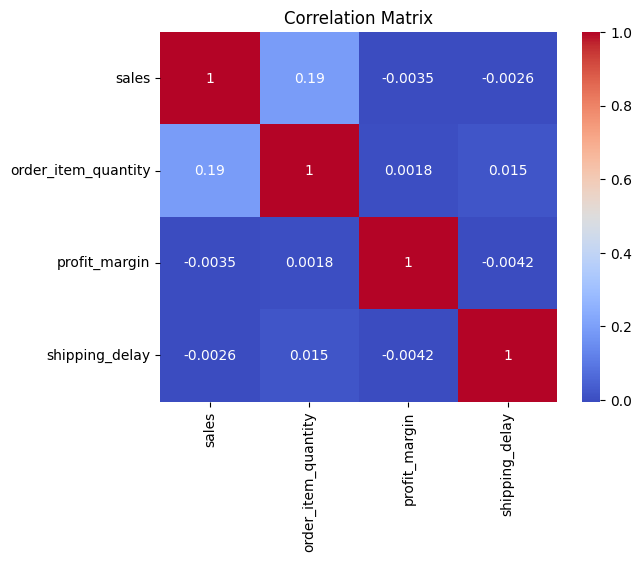

In [15]:
corr = df[['sales','order_item_quantity','profit_margin','shipping_delay']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### Correlation Analysis

A correlation matrix was generated to analyze relationships between key numerical variables including sales, order quantity, profit margin, and shipping delay.

Results show:

- Sales and order quantity have a weak positive correlation (0.19).
- Profit margin and shipping delay show almost no correlation with sales.
- Overall correlations between variables are relatively weak.

Conclusion:

Sales performance in the supply chain dataset appears to be influenced by multiple factors rather than a single dominant variable. This justifies the need for advanced predictive models in later phases.
Overall Conclusion:

Most numerical variables show weak correlations,
indicating that sales behavior is influenced by
multiple factors rather than a single dominant variable.

Test 5 : Seasonal Demand ANOVA

H0: Demand does NOT vary by month
H1: Demand varies seasonally

In [16]:
groups = [group["sales"].values 
          for name, group in df.groupby("order_month")]

from scipy import stats

f_stat, p_value = stats.f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 39.10414044109958
P-value: 3.4335044977342176e-85


In [17]:
if p_value < 0.05:
    print("Reject H0 → Demand varies significantly across months (seasonality exists)")
else:
    print("Fail to reject H0 → No significant seasonal variation in demand")

Reject H0 → Demand varies significantly across months (seasonality exists)


### ANOVA Test: Monthly Demand Seasonality

Hypothesis:

H0: Demand does NOT vary by month  
H1: Demand varies across months  

Results:

F-statistic = 39.10  
P-value = 3.43e-85  

Since the p-value is significantly less than 0.05, we reject the null hypothesis.

Conclusion:

Demand varies significantly across different months, indicating the presence of seasonal patterns in the dataset.



Business Insights :
Seasonal demand patterns are critical for supply chain planning. Businesses can use this insight to optimize inventory levels, forecast demand more accurately, and allocate logistics resources efficiently during high-demand periods.

Test 6 : Granger Causality

In [18]:
ts = df.groupby('order_date_dateorders')[['sales','shipping_delay']].mean()

ts = ts.dropna()

ts.head()

,sales,shipping_delay
order_date_dateorders,,
2015-01-01 00:00:00,299.980011,-2.0
2015-01-01 00:21:00,193.326670,-1.0
2015-01-01 01:03:00,174.962502,1.0
2015-01-01 01:24:00,225.972008,2.0
2015-01-01 02:06:00,193.306671,1.0


In [19]:
from statsmodels.tsa.stattools import grangercausalitytests

grangercausalitytests(ts[['sales','shipping_delay']], maxlag=3)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.6385  , p=0.4243  , df_denom=53303, df_num=1
ssr based chi2 test:   chi2=0.6385  , p=0.4242  , df=1
likelihood ratio test: chi2=0.6385  , p=0.4242  , df=1
parameter F test:         F=0.6385  , p=0.4243  , df_denom=53303, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.4292  , p=0.6510  , df_denom=53300, df_num=2
ssr based chi2 test:   chi2=0.8585  , p=0.6510  , df=2
likelihood ratio test: chi2=0.8585  , p=0.6510  , df=2
parameter F test:         F=0.4292  , p=0.6510  , df_denom=53300, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.5481  , p=0.6494  , df_denom=53297, df_num=3
ssr based chi2 test:   chi2=1.6444  , p=0.6494  , df=3
likelihood ratio test: chi2=1.6444  , p=0.6494  , df=3
parameter F test:         F=0.5481  , p=0.6494  , df_denom=53297, df_num=3


{np.int64(1): ({'ssr_ftest': (np.float64(0.6385086320279797),
    np.float64(0.42425492006305443),
    np.float64(53303.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(0.6385445685774438),
    np.float64(0.42423832183383203),
    np.int64(1)),
   'lrtest': (np.float64(0.6385407440830022),
    np.float64(0.42423970932863964),
    np.int64(1)),
   'params_ftest': (np.float64(0.6385086320492042),
    np.float64(0.4242549200553541),
    np.float64(53303.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(0.4292293812496134),
    np.float64(0.6510128327082241),
    np.float64(53300.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(0.8585392933399866),
    np.float64(0.6509843697450681),
    np.int64(2)),
   'lrtest': (np.float64(0.858532379497774),
    np.float64(0.6509866201505656),
    np.int64(2)),
   'params_ftest': (np.float64(0.4292293812508292),
    np.float64(0.6510128327074325),
    np.float64(53300.0),
    2.0)},
   array([[0., 0., 1., 0., 0

### Granger Causality Test: Shipping Delay vs Sales

Hypothesis:

H0: Shipping delay does NOT influence sales over time  
H1: Shipping delay influences sales trends  

Results:

Lag 1 p-value = 0.424  
Lag 2 p-value = 0.651  
Lag 3 p-value = 0.649  

Since all p-values are greater than 0.05, we fail to reject the null hypothesis.

Conclusion:

Shipping delay does not significantly Granger-cause changes in sales trends over time.




Business Insights :
The analysis indicates that delivery delays do not directly impact sales trends. This suggests that customer purchasing behavior may depend more on product demand, pricing strategies, and seasonal factors rather than logistics delays.